In [135]:
import numpy as np,gc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display
import seaborn as sns
import scipy as sp
from scipy import stats
import datetime
import os
import seaborn.objects as so
import statsmodels.api as sm
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE, SMOTENC
from sklearn.model_selection import StratifiedKFold

import optuna
from optuna import Trial

from utils import *

In [ ]:
train = pd.read_csv('data/train_preprocessed.csv')
test = pd.read_csv('data/test_preprocessed.csv')

TranID = pd.read_csv('test_dropped.csv')["TransactionID"]

In [35]:
cat_features = ["ProductCD", "P_emaildomain", "R_emaildomain", "card1",'card2', "card3", "card4", "card5","card6",
                'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9','addr1', 'addr2',
                'id_12','id_15', 'id_16','id_28','id_29', 'id_30','id_31','id_32','id_33','id_34','id_35','id_36','id_37','id_38',
                'DeviceType', 'DeviceInfo', 'Weekday', 'Hour', 'Day', 'uid']

In [36]:
for col in cat_features:
    for df in [train, test]:
        df[col] = df[col].astype(str)
        df[col] = df[col].fillna('unknown')
        df[col] = df[col].astype('category')

In [41]:
resumetable(train)

Dataset Shape: (590540, 224)


,Name,dtypes,Missing,% of Missing,Uniques,First Value,Second Value,Third Value
0,isFraud,int64,0,0.00%,2,0,0,0
1,TransactionDT,int64,0,0.00%,573349,86400,86401,86469
2,TransactionAmt,float64,0,0.00%,20902,68.5,29.0,59.0
3,ProductCD,category,0,0.00%,5,W,W,W
4,card1,category,0,0.00%,13553,13926,2755,4663
...,...,...,...,...,...,...,...,...
219,uid_mean,float64,0,0.00%,45878,68.5,29.0,73.5
220,uid_std,float64,0,0.00%,44750,-999.0,-999.0,17.058722
221,Weekday,category,0,0.00%,7,5,5,5
222,Hour,category,0,0.00%,24,0,0,0


In [ ]:
X = train.drop('isFraud', axis=1)
y = train['isFraud']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Optuna 를 이용한 LGBM 하이퍼파라미터 튜닝

- 탐색 대상 파라미터 : num_leaves, min_child_samples, subsample, colsample_bytree, reg_alpha, reg_lambda
- 탐색 방식 - 시간자원을 고려하여 3-fold 로 분리하여 각 fold 의 validation roc-auc평균의 최대값 탐색


In [ ]:
def objective(trial, X, y, n_splits=3, random_state=42):
    param = {
        'learning_rate': 0.01,
        'num_leaves': trial.suggest_int('num_leaves', 200, 300),
        'max_depth': -1,
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 1.0, log=True),
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'n_estimators': 4000
    }

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    auc_scores = []

    for train_idx, valid_idx in skf.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_features)
        val_data = lgb.Dataset(X_valid, label=y_valid, reference=train_data, categorical_feature=cat_features)

        model = lgb.train(
            param,
            train_data,
            valid_sets=[val_data],
            valid_names=["val"],
            callbacks=[
                lgb.early_stopping(100, verbose=False),
                lgb.log_evaluation(500)
            ]
        )

        y_pred = model.predict(X_valid)
        auc = roc_auc_score(y_valid, y_pred)
        auc_scores.append(auc)

    return np.mean(auc_scores)


study = optuna.create_study(direction='maximize')
study.optimize(lambda trial: objective(trial, X, y), n_trials=30)  # 원하는 횟수 조절


[I 2025-05-20 16:56:41,125] A new study created in memory with name: no-name-d3cb03ce-0d26-42ac-9c29-a985f3ebc5e5
/opt/anaconda3/envs/ML_practice/lib/python3.8/site-packages/lightgbm/engine.py:204: UserWarning:

Found `n_estimators` in params. Will use it instead of argument



[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 13775, number of negative: 379918
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.087192 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 41212
[LightGBM] [Info] Number of data points in the train set: 393693, number of used features: 222
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034989 -> initscore=-3.317100
[LightGBM] [Info] Start training from score -3.317100
[500]	val's auc: 0.972239
[1000]	val's auc: 0.976967
[1500]	val's auc: 0.977907
[2000]	val's auc: 0.978326
[2500]	val's auc: 0.978615
[3000]	val's auc: 0.978674


/opt/anaconda3/envs/ML_practice/lib/python3.8/site-packages/lightgbm/engine.py:204: UserWarning:

Found `n_estimators` in params. Will use it instead of argument



[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 13775, number of negative: 379918
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.093741 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 41167
[LightGBM] [Info] Number of data points in the train set: 393693, number of used features: 222
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034989 -> initscore=-3.317100
[LightGBM] [Info] Start training from score -3.317100
[500]	val's auc: 0.968942
[1000]	val's auc: 0.97401
[1500]	val's auc: 0.975255
[2000]	val's auc: 0.975607


/opt/anaconda3/envs/ML_practice/lib/python3.8/site-packages/lightgbm/engine.py:204: UserWarning:

Found `n_estimators` in params. Will use it instead of argument



...

/opt/anaconda3/envs/ML_practice/lib/python3.8/site-packages/lightgbm/engine.py:204: UserWarning:

Found `n_estimators` in params. Will use it instead of argument



[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 13775, number of negative: 379918
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.110659 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 41167
[LightGBM] [Info] Number of data points in the train set: 393693, number of used features: 222
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034989 -> initscore=-3.317100
[LightGBM] [Info] Start training from score -3.317100
[500]	val's auc: 0.969183
[1000]	val's auc: 0.974047
[1500]	val's auc: 0.975007
[2000]	val's auc: 0.975273
[2500]	val's auc: 0.975466


/opt/anaconda3/envs/ML_practice/lib/python3.8/site-packages/lightgbm/engine.py:204: UserWarning:

Found `n_estimators` in params. Will use it instead of argument



[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 13776, number of negative: 379918
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.133895 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 41260
[LightGBM] [Info] Number of data points in the train set: 393694, number of used features: 222
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034992 -> initscore=-3.317027
[LightGBM] [Info] Start training from score -3.317027
[500]	val's auc: 0.971973
[1000]	val's auc: 0.976271
[1500]	val's auc: 0.977065
[2000]	val's auc: 0.977399


[I 2025-05-21 03:30:31,826] Trial 29 finished with value: 0.9770171935445536 and parameters: {'num_leaves': 210, 'min_child_samples': 37, 'subsample': 0.9452535088027261, 'colsample_bytree': 0.6165447656814562, 'reg_alpha': 0.002264422627653628, 'reg_lambda': 0.010822994556204012}. Best is trial 24 with value: 0.9774853683234062.


In [120]:
import pickle

with open("study_lgbm.pkl", "wb") as f:
    pickle.dump(study, f)

In [121]:
study.best_params

{'num_leaves': 219,
 'min_child_samples': 22,
 'subsample': 0.879612109043481,
 'colsample_bytree': 0.5013834796917586,
 'reg_alpha': 0.01894950938047488,
 'reg_lambda': 0.0038279012664789685}

## LGBM with best params
- 추가적인 수동 튜닝 진행
- 수동 튜닝의 후보 : 학습률, 규제 관련 파라미터

In [ ]:
best_params_lgbm =  {
                    'learning_rate': 0.005, 
                    'num_leaves': 219, 
                    'max_depth': -1, 
                    'min_child_samples': 22, 
                    'subsample': 0.88, 
                    'colsample_bytree': 0.5, 
                    'reg_alpha': 0.2,
                    'reg_lambda': 0.2,
                    'objective': 'binary',
                    'metric': 'auc',
                    'boosting_type': 'gbdt',
                    'n_estimators': 4000
                    }

In [ ]:
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_features)
val_data = lgb.Dataset(X_test, label=y_test, reference=train_data, categorical_feature=cat_features)

model = lgb.train(
    best_params_lgbm,
    train_data,
    valid_sets=[val_data],
    valid_names=["val"],
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)]
)


/opt/anaconda3/envs/ML_practice/lib/python3.8/site-packages/lightgbm/engine.py:204: UserWarning:

Found `n_estimators` in params. Will use it instead of argument



[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 16421, number of negative: 456011
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.091464 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 41162
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 222
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034758 -> initscore=-3.323956
[LightGBM] [Info] Start training from score -3.323956
Training until validation scores don't improve for 100 rounds
[200]	val's auc: 0.95024
[400]	val's auc: 0.961246
[600]	val's auc: 0.967814
[800]	val's auc: 0.971449
[1000]	val's auc: 0.973799
[1200]	val's au

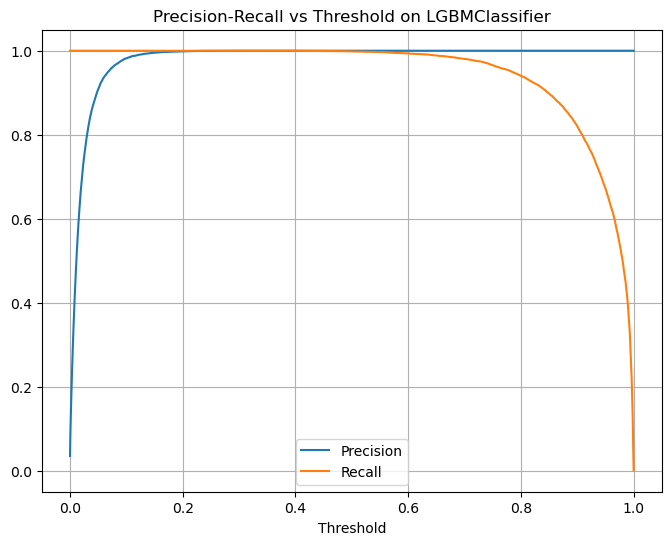

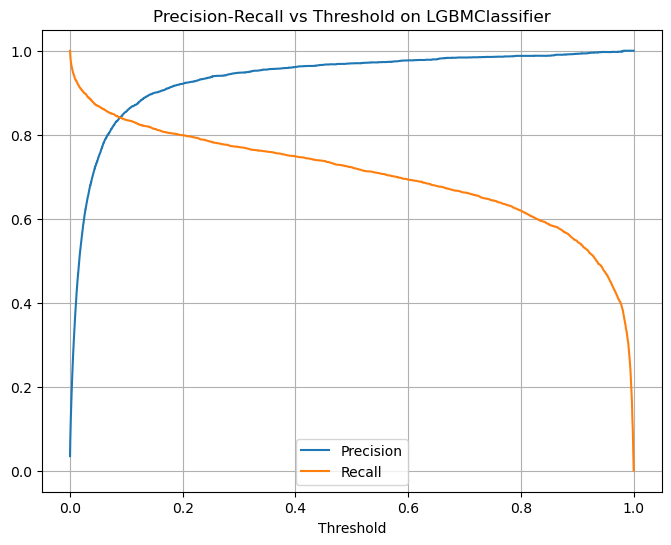

In [ ]:
pr_curve(X_train, y_train, [model])
pr_curve(X_test, y_test, [model])

## Stratify 5-fold로 각 모델을 훈련

In [198]:
models_lgb = []
auc_scores_lgb = []
train_pred_lgbm = np.zeros(len(X_train))
test_pred_lgbm = np.zeros(len(X_test))


n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # LightGBM
    model_lgb = LGBMClassifier(**best_params_lgbm, random_state=1234, n_jobs=-1)
    model_lgb.fit(X_tr, y_tr)
    lgb_val_pred = model_lgb.predict_proba(X_val)[:, 1]
    lgb_test_pred = model_lgb.predict_proba(X_test)[:, 1]

    train_pred_lgbm[val_idx] = lgb_val_pred
    test_pred_lgbm += lgb_test_pred / n_splits

    # AUC
    auc_lgb = roc_auc_score(y_val, lgb_val_pred)
    auc_scores_lgb.append(auc_lgb)
    print(f"Fold {fold + 1}/{n_splits} - AUC: {auc_lgb:.4f}")

    # Save model
    models_lgb.append(model_lgb)

print(f"Mean AUC: {np.mean(auc_scores_lgb):.4f} ± {np.std(auc_scores_lgb):.4f}")

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 13137, number of negative: 364808
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.073942 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 41180
[LightGBM] [Info] Number of data points in the train set: 377945, number of used features: 222
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034759 -> initscore=-3.323939
[LightGBM] [Info] Start training from score -3.323939
Fold 1/5 - AUC: 0.9791
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may

- 변수 중요도 확인

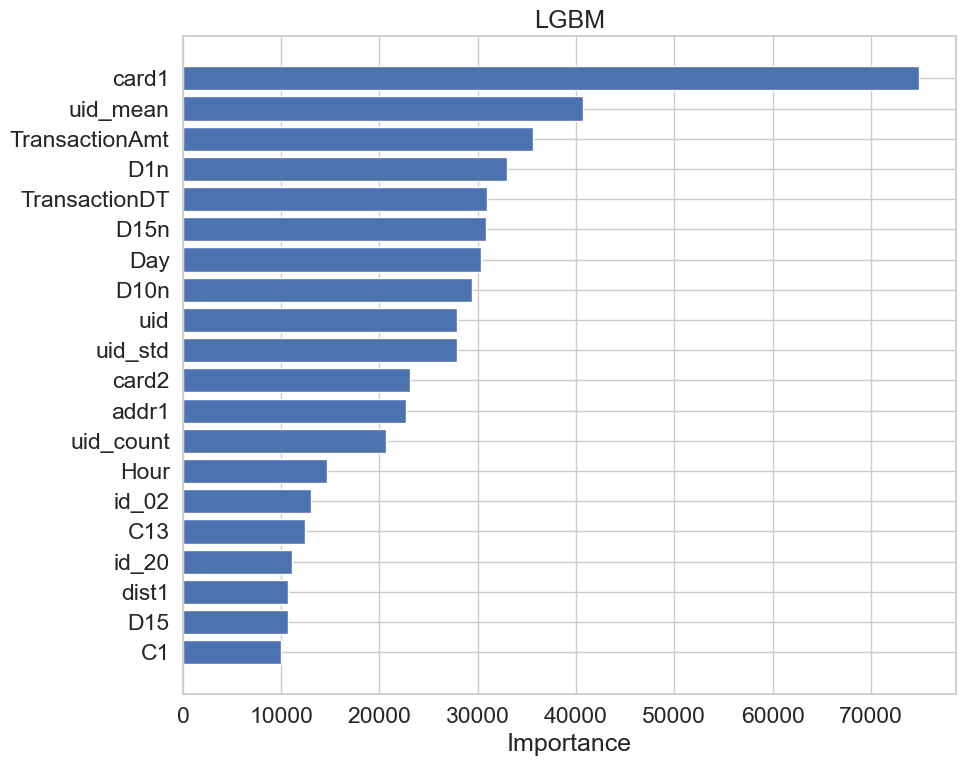

In [311]:
plot_feature_importance(models_lgb[0].feature_importances_, X_train.columns, top_n = 20, title= 'LGBM')

In [199]:
test_preds_lgb = np.zeros(len(test))
for i, model in enumerate(models_lgb):
    pred_prob = model.predict_proba(test)[:, 1]
    test_preds_lgb += pred_prob / n_splits
submission = pd.DataFrame({
    'TransactionID': TranID,
    'isFraud': test_preds_lgb
})
submission.to_csv('submission_lgbm_5fold.csv', index=False)

In [313]:
print(f"roc-auc train : {roc_auc_score(y_train, models_lgb[0].predict(X_train))}")
print(f"roc-auc test : {roc_auc_score(y_test, models_lgb[0].predict(X_test))}")

roc-auc train : 0.9700279929280768
roc-auc test : 0.8554159685272547


## CatBoost

- min_data_in_leaf, subsample, rsm
- 수동 튜님 대상 파라미터 learning_rate, rsm, l2_leaf_reg, random_strength
- 몇가지 후보 조합을 선출한 후 파라미터 선택 진행

In [ ]:
catboost_params = {
    'min_data_in_leaf': best_params_lgbm['min_child_samples'],  # 동일
    'learning_rate': 0.1,
    'subsample': best_params_lgbm['subsample'],              # 동일
    'rsm': best_params_lgbm['colsample_bytree'] + 0.3,       # colsample_bytree -> rsm    
    'l2_leaf_reg': 3,
    'random_strength': 1,
    'cat_features': cat_features,
    'verbose': 100,
    'random_state': 1234,
    'iterations': 1000,
    'eval_metric': 'AUC'
}
  


====== CatBoost ======
0:	test: 0.6265743	best: 0.6265743 (0)	total: 988ms	remaining: 16m 26s
100:	test: 0.9808566	best: 0.9808566 (100)	total: 2m 21s	remaining: 20m 59s
200:	test: 0.9830627	best: 0.9830627 (200)	total: 4m 33s	remaining: 18m 8s
300:	test: 0.9839333	best: 0.9839333 (300)	total: 6m 56s	remaining: 16m 6s
400:	test: 0.9843706	best: 0.9843706 (400)	total: 9m 46s	remaining: 14m 35s
500:	test: 0.9847932	best: 0.9847932 (500)	total: 12m 18s	remaining: 12m 16s
600:	test: 0.9851735	best: 0.9851852 (599)	total: 15m 10s	remaining: 10m 4s
700:	test: 0.9854895	best: 0.9854895 (700)	total: 17m 53s	remaining: 7m 37s
800:	test: 0.9856415	best: 0.9856416 (799)	total: 20m 36s	remaining: 5m 7s
900:	test: 0.9857696	best: 0.9857725 (897)	total: 23m 31s	remaining: 2m 35s
999:	test: 0.9858617	best: 0.9858617 (999)	total: 25m 48s	remaining: 0us

bestTest = 0.9858617103
bestIteration = 999


=========Train data Information=========
Accuracy: 0.9989
ROC-AUC: 0.9998
F1 Score: 0.9841
PR-AUC: 0.99

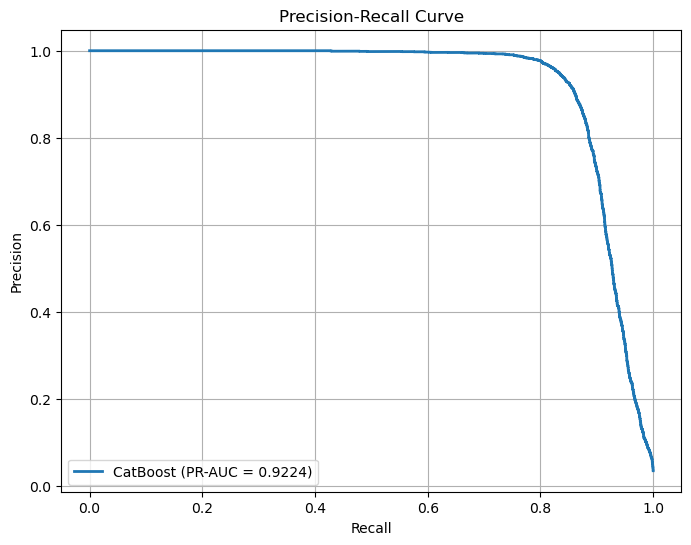

In [ ]:
result, models = evaluate_boosting_models(X_train, X_test, y_train, y_test, threshold=0.2,
                                         models_to_run=["CatBoost"], train_output=True,
                                         cat_params=catboost_params)

In [194]:
models[0].get_all_params()

{'nan_mode': 'Min',
 'eval_metric': 'AUC',
 'combinations_ctr': ['Borders:CtrBorderCount=15:CtrBorderType=Uniform:TargetBorderCount=1:TargetBorderType=MinEntropy:Prior=0/1:Prior=0.5/1:Prior=1/1',
  'Counter:CtrBorderCount=15:CtrBorderType=Uniform:Prior=0/1'],
 'iterations': 1000,
 'sampling_frequency': 'PerTree',
 'fold_permutation_block': 0,
 'leaf_estimation_method': 'Newton',
 'random_score_type': 'NormalWithModelSizeDecrease',
 'counter_calc_method': 'SkipTest',
 'grow_policy': 'SymmetricTree',
 'penalties_coefficient': 1,
 'boosting_type': 'Plain',
 'model_shrink_mode': 'Constant',
 'feature_border_type': 'GreedyLogSum',
 'ctr_leaf_count_limit': 18446744073709551615,
 'bayesian_matrix_reg': 0.10000000149011612,
 'one_hot_max_size': 2,
 'eval_fraction': 0,
 'force_unit_auto_pair_weights': False,
 'l2_leaf_reg': 3,
 'random_strength': 1,
 'rsm': 0.8013834953308105,
 'boost_from_average': False,
 'max_ctr_complexity': 4,
 'model_size_reg': 0.5,
 'simple_ctr': ['Borders:CtrBorderCount

In [144]:
# submission
pred = models[0].predict_proba(test)[:, 1]
submission = pd.DataFrame({'TransactionID': TranID, 'isFraud': pred})
submission.to_csv('submission_cat_optuna_1.csv', index=False)

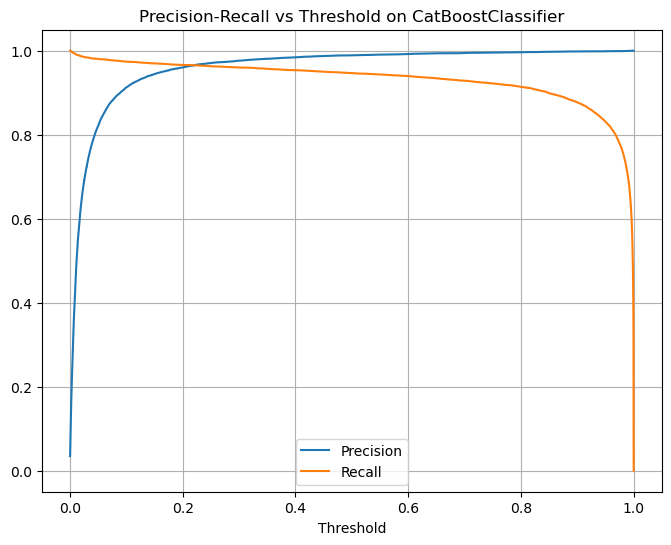

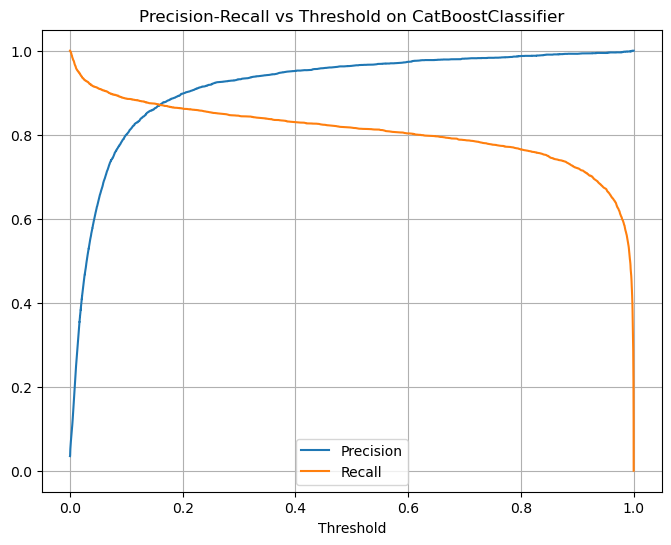

In [ ]:
pr_curve(X_train, y_train, models)
pr_curve(X_test, y_test, models) #과적합 양상

## CatBoost 5-fold 훈련

In [204]:
models_cat = []
auc_scores_cat = []
train_pred_catboost = np.zeros(len(X_train))
test_pred_catboost = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    
    model_cat = CatBoostClassifier(**catboost_params)
    model_cat.fit(X_tr, y_tr, eval_set=(X_val, y_val), verbose=100)
    cat_val_pred = model_cat.predict_proba(X_val)[:, 1]
    cat_test_pred = model_cat.predict_proba(X_test)[:, 1]

    train_pred_catboost[val_idx] = cat_val_pred
    test_pred_catboost += cat_test_pred / n_splits
    
    # AUC
    auc_cat = roc_auc_score(y_val, cat_val_pred)
    auc_scores_cat.append(auc_cat)
    print(f"Fold {fold + 1}/{n_splits} - AUC: {auc_cat:.4f}")

    # Save the model
    models_cat.append(model_cat)

print(f"Mean AUC: {np.mean(auc_scores_cat):.4f} ± {np.std(auc_scores_cat):.4f}")

0:	test: 0.6813146	best: 0.6813146 (0)	total: 954ms	remaining: 15m 52s
100:	test: 0.9800779	best: 0.9800779 (100)	total: 1m 49s	remaining: 16m 13s
200:	test: 0.9820784	best: 0.9820784 (200)	total: 3m 16s	remaining: 13m 1s
300:	test: 0.9831675	best: 0.9831675 (300)	total: 4m 47s	remaining: 11m 6s
400:	test: 0.9838971	best: 0.9838971 (400)	total: 6m 19s	remaining: 9m 27s
500:	test: 0.9843214	best: 0.9843214 (500)	total: 7m 48s	remaining: 7m 47s
600:	test: 0.9846371	best: 0.9846371 (600)	total: 9m 22s	remaining: 6m 13s
700:	test: 0.9847794	best: 0.9847794 (700)	total: 11m 2s	remaining: 4m 42s
800:	test: 0.9849771	best: 0.9849777 (799)	total: 13m 10s	remaining: 3m 16s
900:	test: 0.9851329	best: 0.9851351 (894)	total: 18m	remaining: 1m 58s
999:	test: 0.9853290	best: 0.9853301 (997)	total: 19m 30s	remaining: 0us

bestTest = 0.9853301077
bestIteration = 997

Shrink model to first 998 iterations.
Fold 1/5 - AUC: 0.9853
0:	test: 0.6720587	best: 0.6720587 (0)	total: 704ms	remaining: 11m 42s
100:

- 변수 중요도 확인

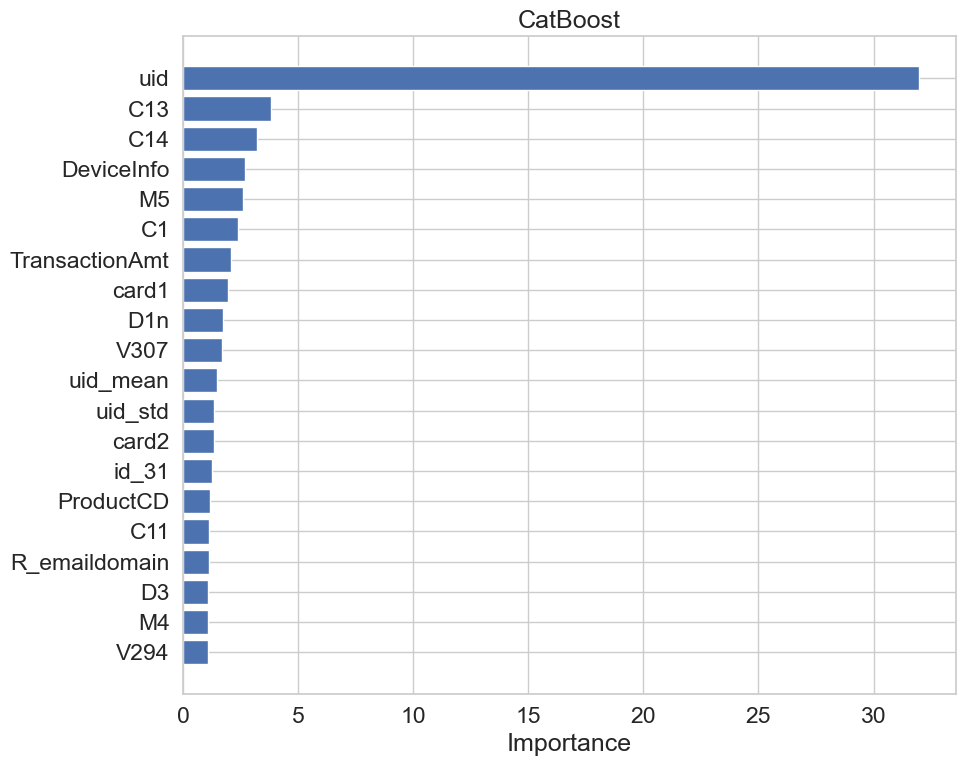

In [290]:
plot_feature_importance(models_cat[0].feature_importances_, X_train.columns, top_n = 20, title= 'CatBoost')

In [205]:
test_preds_cat = np.zeros(len(test))

for i, model in enumerate(models_cat):
    pred_prob = model.predict_proba(test)[:, 1]
    test_preds_cat += pred_prob / n_splits

submission = pd.DataFrame({
    'TransactionID': TranID,
    'isFraud': test_preds_cat
})
submission.to_csv('submission_cat_5fold.csv', index=False)

In [314]:
print(f"roc-auc train : {roc_auc_score(y_train, models_cat[0].predict(X_train))}")
print(f"roc-auc test : {roc_auc_score(y_test, models_cat[0].predict(X_test))}")

roc-auc train : 0.9736405250014596
roc-auc test : 0.9034355423593476


## 앙상블 모델 훈련

In [206]:
from sklearn.linear_model import LogisticRegression

In [212]:
X_train

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,D1n,D10n,D15n,uid,uid_count,uid_mean,uid_std,Weekday,Hour,Day
5307,174911,59.000,W,4988,334.0,150.0,visa,226.0,debit,315.0,...,2.0,2.0,2.0,4988_315.0_2.0_Gmail,1,59.000000,-999.000000,6,0,3
191582,4301977,23.378,C,3867,296.0,185.0,visa,226.0,credit,-999.0,...,49.0,49.0,49.0,3867_-999.0_49.0_Gmail,1,23.378000,-999.000000,4,18,19
260168,6229929,35.950,W,12577,268.0,150.0,visa,166.0,debit,476.0,...,65.0,1.0,-348.0,12577_476.0_65.0_Gmail,6,32.450000,5.049752,6,2,11
18516,497176,100.000,R,6019,583.0,150.0,visa,226.0,credit,126.0,...,-206.0,-206.0,5.0,6019_126.0_-206.0_Verizon,1,100.000000,-999.000000,2,18,6
47538,1124702,75.000,H,16075,514.0,150.0,mastercard,102.0,credit,325.0,...,13.0,1012.0,1012.0,16075_325.0_13.0_Gmail,2,62.500000,17.677670,3,0,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110268,2157580,25.000,H,16796,555.0,210.0,visa,137.0,debit,296.0,...,24.0,1023.0,1023.0,16796_296.0_24.0_Microsoft,3,25.000000,0.000000,0,23,25
259178,6213562,357.950,W,16727,111.0,150.0,visa,226.0,credit,325.0,...,71.0,71.0,71.0,16727_325.0_71.0_Gmail,2,220.450000,194.454365,5,21,10
365838,9076295,156.000,W,3283,555.0,150.0,visa,226.0,debit,191.0,...,75.0,-156.0,-156.0,3283_191.0_75.0_Gmail,15,97.266667,70.314057,4,1,16
131932,2614452,59.000,W,9500,321.0,150.0,visa,226.0,debit,204.0,...,-341.0,-341.0,30.0,9500_204.0_-341.0_Yahoo,1,59.000000,-999.000000,6,6,31


In [ ]:

# stacking data
stack_train = np.vstack([train_pred_lgbm, train_pred_catboost]).T  
stack_test = np.vstack([test_pred_lgbm, test_pred_catboost]).T

# stacking model
meta_model = LogisticRegression()
meta_model.fit(stack_train, y_train)

stack_pred_train = meta_model.predict_proba(stack_train)[:, 1]
stack_pred_test = meta_model.predict_proba(stack_test)[:, 1]

print("Stacking Model Train ROC AUC:", roc_auc_score(y_train, stack_pred_train))
print("Stacking Model Test ROC AUC:", roc_auc_score(y_test, stack_pred_test))

Stacking Model Train ROC AUC: 0.9841511585763729
Stacking Model Test ROC AUC: 0.9866230617255402


In [ ]:
# 최종 제출파일

stack_test_submission = np.stack([test_preds_lgb, test_preds_cat], axis=1) 


test_submission = meta_model.predict_proba(stack_test_submission)[:, 1]

submission = pd.DataFrame({
    'TransactionID': TranID,
    'isFraud': test_submission
})
submission.to_csv('submission_stacking.csv', index=False)

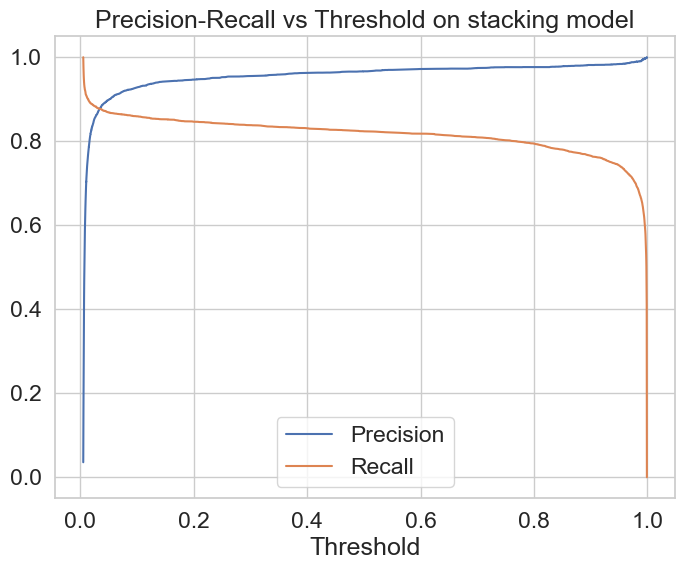

In [304]:
precisions, recalls, thresholds = precision_recall_curve(y_test, stack_pred_test)
plt.figure(figsize=(8,6))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel("Threshold")
plt.legend()
plt.title(f'Precision-Recall vs Threshold on stacking model')
plt.grid(True)
plt.show()

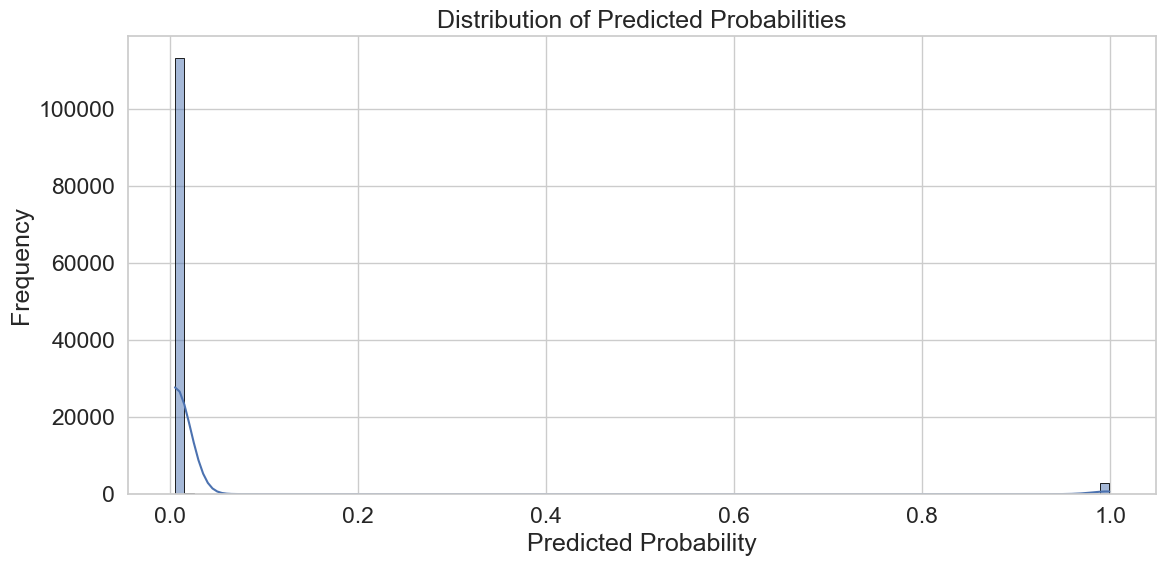

In [323]:
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid", font_scale=1.5)
sns.histplot(stack_pred_test, bins=100, kde=True, edgecolor='black')
plt.title("Distribution of Predicted Probabilities")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

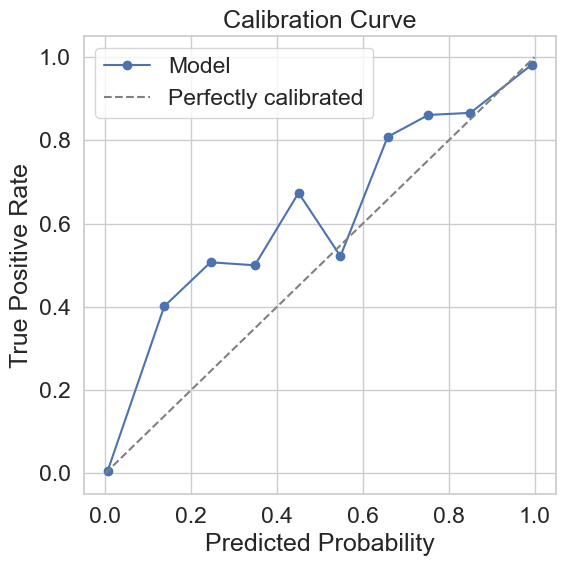

In [316]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, stack_pred_test, n_bins=10, strategy='uniform')

# 시각화
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
plt.title('Calibration Curve')
plt.xlabel('Predicted Probability')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [325]:
thresholds = np.linspace(0, 1, 500)
f1_scores = [f1_score(y_test, stack_pred_test > t) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
print("Best threshold after calibration:", best_threshold)

Best threshold after calibration: 0.15230460921843686


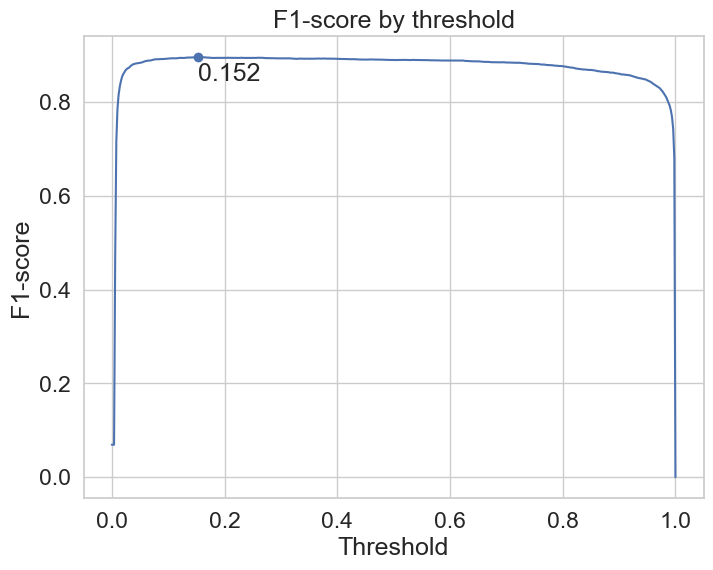

In [337]:
plt.figure(figsize=(8, 6))
plt.plot(thresholds, f1_scores)
plt.scatter(best_threshold, f1_score(y_test, stack_pred_test > best_threshold))
plt.text(best_threshold, f1_score(y_test, stack_pred_test > best_threshold) - 0.05 ,"0.152")
plt.title('F1-score by threshold')
plt.xlabel('Threshold')
plt.ylabel('F1-score')
plt.show()
